# MuscaDet - A multiscale and uncertainty-aware detector of cloud-free periods in time series of 1 min measurements of solar irradiance at ground level

Detecting cloud-free periods in time series of measurements of solar irradiance at ground level is essential in many domains, from meteorology to management of photovoltaic systems, including verification of so-called clear-sky models such as the McClear service of the Copernicus Atmosphere Monitoring Service. However, current cloud-free detectors call themselves on clear-sky models to discard measurements that are not close enough to the model outputs, introducing potential biases that pose a problem for the quarterly verification of the McClear service carried out in our institute on behalf of Copernicus. Accordingly, a new multiscale detector called MuscaDet was devised that is based on the correlations between measurements and a locally fitted Lambert-Beer-type function computed over a cascade of temporal windows of different lengths. This approach ensures that the detection remains independent of any predefined clear-sky model while still leveraging the dependence of the irradiance on the solar zenithal angle in cloud-free conditions. Measurement uncertainty and natural atmospheric variability are accommodated through a dynamic tolerance depending on the solar zenithal angle. MuscaDet is designed to operate on 1 min measurements of irradiance for the specific requirements of evaluation of clear-sky models. It needs measurements of the irradiance and its direct or diffuse component to discard overcast conditions. For its verification, time series spanning several years were collected at seven stations of the Baseline Surface Radiation Network covering various climates. Visual inspections of the measurements and outputs of MuscaDet show that the detector is accurate even in cases of short-lived isolated clouds or ramping cloudy events. Most cloud-free instants are detected and no visually-detected clouds are falsely noted as cloud-free by MuscaDet. A comparison with the currently used cloud-free detector indicates that MuscaDet provides a more balanced statistical distribution of solar zenithal angles, thus improving the verification of the McClear service. MuscaDet is easy to implement and needs no external input except the solar zenithal angle which is easily computed using existing libraries.

## Import of the required library

sg2 can be installed with "pip install sg2" (https://pypi.org/project/sg2/)

In [78]:
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
from matplotlib.dates import HourLocator
import matplotlib.dates as mdates
import sg2
import lib_MuscaDet

## Import of surface solar irradiance measurements

We use data hosted on the thredds server https://tds.webservice-energy.org/

In [82]:
Year=2025
StationID='DRA'
url_nc=fr"https://tds.webservice-energy.org/thredds/dodsC/surfrad-stations/SURFRAD-{StationID}.nc"
with nc.Dataset(url_nc) as ds:
    lat,lon,elev=ds['latitude'][:].data,ds['longitude'][:].data,ds['elevation'][:].data
    time=ds['time'][:].data*np.timedelta64(1,'s')+np.datetime64('1970-01-01')
    ghi=ds['GHI'][:].data
    dhi=ds['DHI'][:].data
    bni=ds['BNI'][:].data

idx=(time>np.datetime64(f'{Year}-01-01')) & (time<np.datetime64(f'{Year+1}-01-01'))
time=time[idx]
ghi=ghi[idx]
dhi=dhi[idx]
bni=bni[idx]

## Calculation of the sun position

In [64]:
sp=sg2.sun_position([[lon,lat,elev]],time-np.timedelta64(30,'s'),["topoc.gamma_S0","topoc.toa_hi"])
SZA, E0 = np.degrees(np.pi/2-sp.topoc.gamma_S0[0]),sp.topoc.toa_hi[0]       

## Detection of cloud-free instants with MuscaDet

In [66]:
isValid=(SZA<89)
isCloudFree=lib_MuscaDet.CSD_MuScaDet_v2(time,E0,SZA,ghi,dhi,bni,isValid)

Window size=  15 min: 100%|████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 42.63it/s]


## Plot of the results

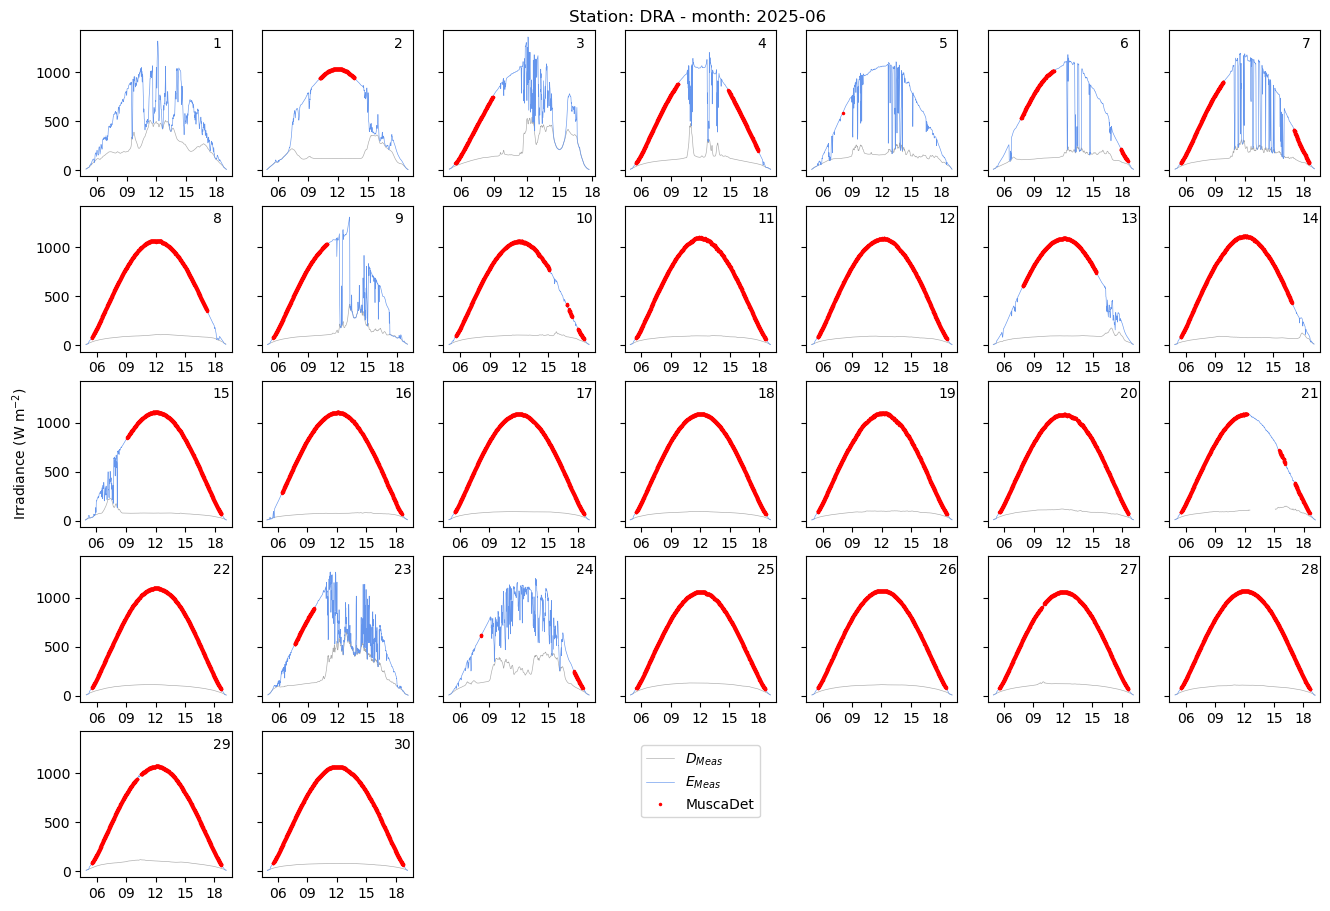

In [84]:
Month=6

Ma = np.datetime64(f"{Year:04d}-{Month:02d}-01")
Mb = np.datetime64(f"{Year+1:04d}-01-01") if Month == 12 else np.datetime64(f"{Year:04d}-{Month+1:02d}-01")
    
fig,axs=plt.subplots(5,7,figsize=(16,11),sharex=False,sharey=True)
axs=axs.flatten()

for ii,D in enumerate(np.arange(Ma,Mb,np.timedelta64(1,'D'))):
    
    MeanLocalTime=time+np.timedelta64(int(lon*24/360*60*60),'s')
    idxD=(MeanLocalTime>=D) & (MeanLocalTime<D+np.timedelta64(1,'D')) & (ghi>5)
        
    mask = np.where(isValid, 1, np.nan)
    axs[ii].plot(MeanLocalTime[idxD],(mask*dhi)[idxD],'-',lw=0.45,color='darkgrey',label="$D_{Meas}$")
    axs[ii].plot(MeanLocalTime[idxD],(mask*ghi)[idxD],'-',lw=0.45,color='cornflowerblue',label="$E_{Meas}$",ms=1)

    idOK=idxD & (isCloudFree>0)
    axs[ii].plot(MeanLocalTime[(idxD) & (isCloudFree>0)],ghi[(idxD) & (isCloudFree>0)],'r.',ms=3,label='MuscaDet')

    axs[ii].xaxis.set_major_locator(HourLocator([6,9,12,15,18]))
    try:
       if np.sum(idxD)>0:
            axs[ii].set_xlim([np.min(MeanLocalTime[idxD]-np.timedelta64(30,'m')),np.max(MeanLocalTime[idxD]+np.timedelta64(30,'m'))])
    except:
       print('pb')
       print(ttt[idxD])
       print(np.min(MeanLocalTime[idxD]-np.timedelta64(30,'m')))
       print(np.max(MeanLocalTime[idxD]+np.timedelta64(30,'m')))
       
    axs[ii].xaxis.set_major_formatter(mdates.DateFormatter('%H'))
YL=axs[ii].get_ylim()
for ii,D in enumerate(np.arange(Ma,Mb,np.timedelta64(1,'D'))):
    XL=axs[ii].get_xlim()
    axs[ii].text(XL[0]+0.875*(XL[1]-XL[0]),YL[0]+0.88*(YL[1]-YL[0]),str(ii+1))

    
for iii in np.arange(ii+1,35):
    axs[iii].axis(False)
axs[14].set_ylabel('Irradiance (W m$^{-2}$)')

axs[3].set_title(fr"Station: {StationID} - month: {str(Ma)[:7]} ")
axs[24].legend(loc='upper center', bbox_to_anchor=(0.5, -0.25))